In [19]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2
using DataFrames
using CSV

In [20]:
using Revise
using Newtrinos
using Newtrinos.osc

In [ ]:

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc);


experiments = (

   gerda= Newtrinos.gerda.configure(physics),
   katrin=Newtrinos.katrin.configure(physics)
);

par= Newtrinos.get_params(experiments)

[ Info: Loading Gerda data
[ Info: Loading Katrin data


(N = 100.0, m₀ = 0.1, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [22]:

all_priors = Newtrinos.get_priors(experiments)


vars_to_scan = ( r=31,  m₀=31)  

modified_priors = (
    N = par.N,
    m₀ =all_priors.m₀,
    r = all_priors.r,
    
   
  

    Δm²₂₁ = par.Δm²₂₁,
    Δm²₃₁ = all_priors.Δm²₃₁,
    δCP = par.δCP,
    θ₁₂ = par.θ₁₂,
    θ₁₃ = all_priors.θ₁₃,
    θ₂₃ = par.θ₂₃
)

(N = 100.0, m₀ = Uniform{Float64}(a=1.0e-7, b=0.015), r = Uniform{Float64}(a=0.0, b=1.0), Δm²₂₁ = 7.53e-5, Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = 0.8556288707523761)

In [23]:
likelihood_NN = Newtrinos.generate_likelihood(experiments);

result_NN = Newtrinos.scan(likelihood_NN, modified_priors, vars_to_scan, par)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:09


NewtrinosResult((r = [0.0, 0.03333333333333333, 0.06666666666666667, 0.1, 0.13333333333333333, 0.16666666666666666, 0.2, 0.23333333333333334, 0.26666666666666666, 0.3  …  0.7, 0.7333333333333333, 0.7666666666666667, 0.8, 0.8333333333333334, 0.8666666666666667, 0.9, 0.9333333333333333, 0.9666666666666667, 1.0], m₀ = [1.0e-7, 0.0005000966666666666, 0.0010000933333333335, 0.0015000900000000001, 0.0020000866666666666, 0.002500083333333333, 0.00300008, 0.0035000766666666667, 0.004000073333333334, 0.00450007  …  0.010500029999999999, 0.011000026666666666, 0.011500023333333333, 0.01200002, 0.012500016666666667, 0.013000013333333333, 0.01350001, 0.014000006666666667, 0.014500003333333332, 0.015]), (N = [100.0 100.0 … 100.0 100.0; 100.0 100.0 … 100.0 100.0; … ; 100.0 100.0 … 100.0 100.0; 100.0 100.0 … 100.0 100.0], Δm²₂₁ = [7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; … ; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5], Δm²₃₁ = [0.00247529999999999

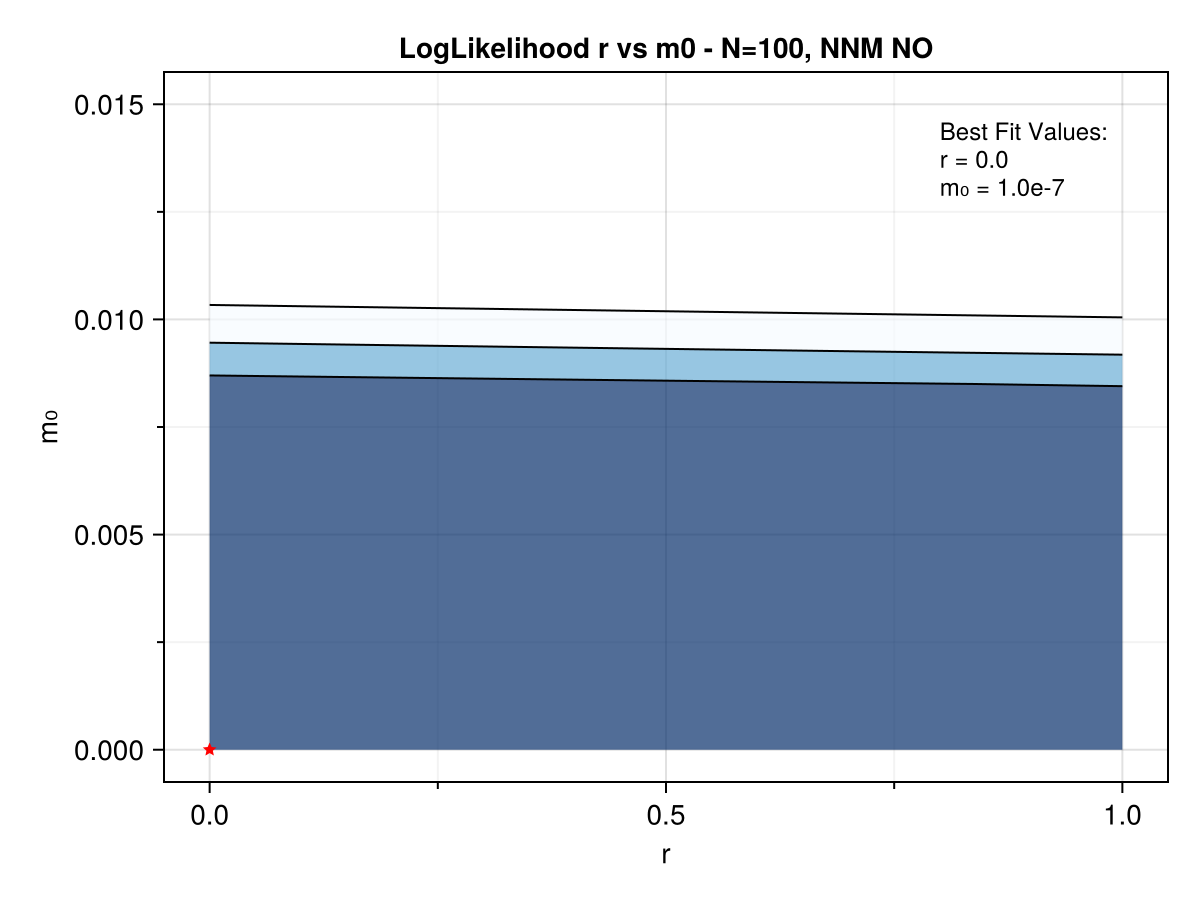

In [24]:
#plot and save the image
using CairoMakie
img = CairoMakie.plot(result_NN; title="LogLikelihood r vs m0 - N=100, NNM NO")
display("image/png", img)
#save("/home/sofialon/Newtrinos.jl/aug_plots/gerda/legend1000_rm0_N100_NNM_NO.png", img)